In [1]:
!pip install -q transformers accelerate datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = "/content/drive/MyDrive/HA_but"
os.makedirs(ROOT, exist_ok=True)

Mounted at /content/drive


In [ ]:
from datasets import load_dataset
import re, random

random.seed(42)

def gold_cevap(text):
    """gsm8k_tr: #### yok, son satırdaki son sayıyı al."""
    satirlar = [s.strip() for s in str(text).strip().split('\n') if s.strip()]
    if not satirlar:
        return None

    son = satirlar[-1]
    son = son.replace('.', '').replace(',', '.')

    sayilar = re.findall(r'-?\d+(?:\.\d+)?', son)
    if not sayilar:
        return None

    try:
        return float(sayilar[-1])
    except:
        return None


def pred_cevap(text):
    text = str(text)

    # Önce istenen #### formatını ara
    m = re.search(r'####\s*([-\d,\.]+)', text)
    if m:
        try:
            return float(m.group(1).replace(',', '.'))
        except:
            pass

    # "cevap 27", "sonuç 27", "nihai cevap 27" gibi ifadeleri ara
    m = re.search(
        r'(?:cevap|sonuç|sonuc|nihai cevap)[^\d\-]*(-?\d+(?:[.,]\d+)*)',
        text.lower()
    )
    if m:
        try:
            return float(m.group(1).replace(',', '.'))
        except:
            pass

    # Son çare: tüm metindeki son sayıyı al
    text2 = text.replace('.', '').replace(',', '.')
    sayilar = re.findall(r'-?\d+(?:\.\d+)?', text2)

    if not sayilar:
        return None

    try:
        return float(sayilar[-1])
    except:
        return None


ds = load_dataset('ytu-ce-cosmos/gsm8k_tr')['train']

sorular = []
for i, ex in enumerate(ds):
    gold = gold_cevap(ex['answer'])
    if gold is None:
        continue

    sorular.append({
        'id': i,
        'soru': ex['question'].strip(),
        'gold': gold,
        'gold_text': ex['answer']
    })

random.shuffle(sorular)

print(f"Toplam veri: {len(ds)}")
print(f"Toplam temiz soru: {len(sorular)}")
print(f"#### içeren cevap sayısı: {sum('####' in str(ex['answer']) for ex in ds)}")

print("\nİlk 3 örnek:")
for ex in sorular[:3]:
    print("-" * 60)
    print("Gold:", ex["gold"])
    print("Soru:", ex["soru"][:120])
    print("Cevap:", ex["gold_text"][:180])

Toplam veri: 8792
Toplam temiz soru: 8721
#### içeren cevap sayısı: 0

İlk 3 örnek:
------------------------------------------------------------
Gold: 3.0
Soru: Junior'ın 16 tavşanı var. Pazartesi günü tavşanları için 6 oyuncak aldı. Çarşamba günü, Pazartesi günü aldığının iki kat
Cevap: Öncelikle Junior'ın her gün aldığı oyuncakları hesaplayalım:

- Pazartesi günü 6 oyuncak aldı.
- Çarşamba günü Pazartesi günü aldığının iki katı kadar, yani 6 * 2 = 12 oyuncak aldı
------------------------------------------------------------
Gold: 27.0
Soru: David ev ödevini 60 dakikada bitirdi. Matematik ödevi için 15 dakika ve heceleme ödevi için 18 dakika harcadı. Zamanının
Cevap: David okumak için 27 dakika harcadı.
------------------------------------------------------------
Gold: 0.0
Soru: Liz her Şükran Günü'nde 2 tane 16 poundluk hindi kızartıyor.  Küçük bir fırını olduğu için her seferinde sadece bir tane
Cevap: Her bir hindi 16 pound olduğuna göre 32 yarım pound eder. 32 yarım pound çarpı 15 

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = 'left'

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model.eval()

terminators = [tokenizer.eos_token_id]
end_turn = tokenizer.convert_tokens_to_ids("<end_of_turn>")

if isinstance(end_turn, int) and end_turn >= 0:
    terminators.append(end_turn)

terminators = list(set(terminators))

print("Model hazır")
print("Terminators:", terminators)
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

config.json:   0%|          | 0.00/853 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

Model hazır
Terminators: [107]
VRAM: 18.5 GB


In [ ]:
def prompt_hazirla(soru):
    return (
        "Soruya kısa ve net cevap ver. "
        "Uzun açıklama yazma. "
        "Yanıtlarında karmaşık matematik notasyonu kullanma. "
        "En son satırda sadece şu formatı yaz: #### <sayı>\n\n"
        f"Soru: {soru}"
    )


@torch.no_grad()
def uret(soru):
    messages = [{"role": "user", "content": prompt_hazirla(soru)}]

    chat_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    inputs = tokenizer(
        chat_text,
        return_tensors="pt"
    ).to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=2048,
        eos_token_id=terminators,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        output_scores=True,
        return_dict_in_generate=True,
    )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = out.sequences[0][prompt_len:]
    metin = tokenizer.decode(gen_ids, skip_special_tokens=True)

    diffs = []
    for step in out.scores:
        probs = torch.softmax(step[0].float(), dim=-1)
        top2 = torch.topk(probs, k=2)
        diffs.append((top2.values[0] - top2.values[1]).item())

    del inputs, out, gen_ids
    torch.cuda.empty_cache()

    return metin, diffs

In [ ]:
import os, json, time

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar.jsonl"

HEDEF_DOGRU = 30
HEDEF_YANLIS = 30
N_RUN = 300
KAYIT_ARALIGI = 10

def kayitlari_oku(path):
    if not os.path.exists(path):
        return []

    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar


def kayitlari_yaz(path, yeni_kayitlar):
    if len(yeni_kayitlar) == 0:
        return

    with open(path, "a", encoding="utf-8") as f:
        for kayit in yeni_kayitlar:
            f.write(json.dumps(kayit, ensure_ascii=False) + "\n")


kayitlar = kayitlari_oku(KAYIT_DOSYASI)

islenen_idler = set(r["id"] for r in kayitlar)
dogru_sayisi = sum(r["dogru"] for r in kayitlar)
yanlis_sayisi = len(kayitlar) - dogru_sayisi

bekleyen_kayitlar = []

print("Önceki kayıt:", len(kayitlar))
print("Doğru:", dogru_sayisi, "Yanlış:", yanlis_sayisi)

basla = time.time()

for q in sorular[:N_RUN]:
    if q["id"] in islenen_idler:
        continue

    metin, diffs = uret(q["soru"])

    pred = pred_cevap(metin)
    dogru = pred is not None and abs(pred - q["gold"]) < 1e-4

    kayit = {
        "id": q["id"],
        "soru": q["soru"],
        "gold": q["gold"],
        "pred": pred,
        "dogru": dogru,
        "diffs": diffs,
        "n_token": len(diffs),
        "metin_kismi": metin[:500]
    }

    bekleyen_kayitlar.append(kayit)
    islenen_idler.add(q["id"])

    if dogru:
        dogru_sayisi += 1
    else:
        yanlis_sayisi += 1

    print(
        f"[{len(islenen_idler)}] "
        f"gold={q['gold']} pred={pred} "
        f"{'DOĞRU' if dogru else 'YANLIŞ'} "
        f"token={len(diffs)} | "
        f"D={dogru_sayisi} Y={yanlis_sayisi}"
    )

    if len(bekleyen_kayitlar) >= KAYIT_ARALIGI:
        kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)
        bekleyen_kayitlar = []
        print("Ara kayıt yazıldı.")

    if dogru_sayisi >= HEDEF_DOGRU and yanlis_sayisi >= HEDEF_YANLIS:
        print("\nKüçük deneme için yeterli dengeli veri toplandı.")
        break

# kalan kayıtları yaz
kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)

son_kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("\n=== SON DURUM ===")
print("Toplam kayıt:", len(son_kayitlar))
print("Doğru:", sum(r["dogru"] for r in son_kayitlar))
print("Yanlış:", len(son_kayitlar) - sum(r["dogru"] for r in son_kayitlar))
print("Kayıt dosyası:", KAYIT_DOSYASI)
print(f"Süre: {(time.time() - basla)/60:.1f} dk")

Önceki kayıt: 0
Doğru: 0 Yanlış: 0
[1] gold=3.0 pred=3.0 DOĞRU token=1091 | D=1 Y=0
[2] gold=27.0 pred=27.0 DOĞRU token=464 | D=2 Y=0
[3] gold=0.0 pred=0.0 DOĞRU token=2048 | D=3 Y=0
[4] gold=100.0 pred=100.0 DOĞRU token=674 | D=4 Y=0
[5] gold=3.0 pred=3.0 DOĞRU token=900 | D=5 Y=0
[6] gold=290.0 pred=465.0 YANLIŞ token=528 | D=5 Y=1
[7] gold=310.0 pred=310.0 DOĞRU token=344 | D=6 Y=1
[8] gold=25.0 pred=25.0 DOĞRU token=1929 | D=7 Y=1
[9] gold=80.0 pred=10.0 YANLIŞ token=2048 | D=7 Y=2


KeyboardInterrupt: 

In [ ]:
from transformers import LogitsProcessor, LogitsProcessorList

class Top1Top2Kaydedici(LogitsProcessor):
    def __init__(self):
        self.farklar = []

    def __call__(self, input_ids, scores):
        probs = torch.softmax(scores.float(), dim=-1)
        top2 = torch.topk(probs, k=2, dim=-1).values
        fark = (top2[:, 0] - top2[:, 1]).detach().cpu().tolist()
        self.farklar.append(fark)
        return scores


def prompt_hazirla(soru):
    return (
        "Sadece kısa cevap ver. "
        "Adım adım uzun çözüm yazma. "
        "Son satır: #### <sayı>\n\n"
        f"Soru: {soru}"
    )


@torch.no_grad()
def uret(soru):
    messages = [{"role": "user", "content": prompt_hazirla(soru)}]

    chat_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    inputs = tokenizer(
        chat_text,
        return_tensors="pt"
    ).to(model.device)

    kaydedici = Top1Top2Kaydedici()

    out = model.generate(
        **inputs,
        max_new_tokens=512,
        eos_token_id=terminators,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        logits_processor=LogitsProcessorList([kaydedici]),
        output_scores=False,
        return_dict_in_generate=True,
    )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = out.sequences[0][prompt_len:]
    metin = tokenizer.decode(gen_ids, skip_special_tokens=True)

    # Burada sadece top1-top2 farkları tutuluyor
    diffs = [float(x[0]) for x in kaydedici.farklar]

    del inputs, out, gen_ids
    torch.cuda.empty_cache()

    return metin, diffs

In [ ]:
import os, json, time

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar.jsonl"

HEDEF_DOGRU = 30
HEDEF_YANLIS = 30
N_RUN = 300
KAYIT_ARALIGI = 10

def kayitlari_oku(path):
    if not os.path.exists(path):
        return []

    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar


def kayitlari_yaz(path, yeni_kayitlar):
    if len(yeni_kayitlar) == 0:
        return

    with open(path, "a", encoding="utf-8") as f:
        for kayit in yeni_kayitlar:
            f.write(json.dumps(kayit, ensure_ascii=False) + "\n")


kayitlar = kayitlari_oku(KAYIT_DOSYASI)

islenen_idler = set(r["id"] for r in kayitlar)
dogru_sayisi = sum(r["dogru"] for r in kayitlar)
yanlis_sayisi = len(kayitlar) - dogru_sayisi

bekleyen_kayitlar = []

print("Önceki kayıt:", len(kayitlar))
print("Doğru:", dogru_sayisi, "Yanlış:", yanlis_sayisi)

basla = time.time()

for q in sorular[:N_RUN]:
    if q["id"] in islenen_idler:
        continue

    metin, diffs = uret(q["soru"])

    pred = pred_cevap(metin)
    dogru = pred is not None and abs(pred - q["gold"]) < 1e-4

    kayit = {
        "id": q["id"],
        "soru": q["soru"],
        "gold": q["gold"],
        "pred": pred,
        "dogru": dogru,
        "diffs": diffs,
        "n_token": len(diffs),
        "metin_kismi": metin[:500]
    }

    bekleyen_kayitlar.append(kayit)
    islenen_idler.add(q["id"])

    if dogru:
        dogru_sayisi += 1
    else:
        yanlis_sayisi += 1

    print(
        f"[{len(islenen_idler)}] "
        f"gold={q['gold']} pred={pred} "
        f"{'DOĞRU' if dogru else 'YANLIŞ'} "
        f"token={len(diffs)} | "
        f"D={dogru_sayisi} Y={yanlis_sayisi}"
    )

    if len(bekleyen_kayitlar) >= KAYIT_ARALIGI:
        kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)
        bekleyen_kayitlar = []
        print("Ara kayıt yazıldı.")

    if dogru_sayisi >= HEDEF_DOGRU and yanlis_sayisi >= HEDEF_YANLIS:
        print("\nKüçük deneme için yeterli dengeli veri toplandı.")
        break

# kalan kayıtları yaz
kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)

son_kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("\n=== SON DURUM ===")
print("Toplam kayıt:", len(son_kayitlar))
print("Doğru:", sum(r["dogru"] for r in son_kayitlar))
print("Yanlış:", len(son_kayitlar) - sum(r["dogru"] for r in son_kayitlar))
print("Kayıt dosyası:", KAYIT_DOSYASI)
print(f"Süre: {(time.time() - basla)/60:.1f} dk")

Önceki kayıt: 0
Doğru: 0 Yanlış: 0
[1] gold=3.0 pred=3.0 DOĞRU token=512 | D=1 Y=0
[2] gold=27.0 pred=27.0 DOĞRU token=463 | D=2 Y=0
[3] gold=0.0 pred=5.0 YANLIŞ token=512 | D=2 Y=1
[4] gold=100.0 pred=3.0 YANLIŞ token=512 | D=2 Y=2
[5] gold=3.0 pred=3.0 DOĞRU token=512 | D=3 Y=2
[6] gold=290.0 pred=465.0 YANLIŞ token=512 | D=3 Y=3
[7] gold=310.0 pred=310.0 DOĞRU token=512 | D=4 Y=3
[8] gold=25.0 pred=25.0 DOĞRU token=512 | D=5 Y=3
[9] gold=80.0 pred=80.0 DOĞRU token=512 | D=6 Y=3
[10] gold=240.0 pred=1.0 YANLIŞ token=512 | D=6 Y=4
Ara kayıt yazıldı.
[11] gold=5.0 pred=8.0 YANLIŞ token=512 | D=6 Y=5
[12] gold=10.0 pred=50.0 YANLIŞ token=512 | D=6 Y=6
[13] gold=96.0 pred=3.0 YANLIŞ token=512 | D=6 Y=7
[14] gold=99.0 pred=99.0 DOĞRU token=512 | D=7 Y=7
[15] gold=9.0 pred=1.0 YANLIŞ token=512 | D=7 Y=8
[16] gold=100.0 pred=100.0 DOĞRU token=512 | D=8 Y=8
[17] gold=4.0 pred=4.0 DOĞRU token=512 | D=9 Y=8
[18] gold=2.0 pred=100.0 YANLIŞ token=512 | D=9 Y=9
[19] gold=36.0 pred=10.0 YANLIŞ tok

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import json, os

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar.jsonl"

def kayitlari_oku(path):
    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("Toplam kayıt:", len(kayitlar))
print("Doğru:", sum(r["dogru"] for r in kayitlar))
print("Yanlış:", len(kayitlar) - sum(r["dogru"] for r in kayitlar))


def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)

    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }


satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df_ozellik = pd.DataFrame(satirlar)

display(df_ozellik.head())
print("Özellik tablosu:", df_ozellik.shape)

Toplam kayıt: 30
Doğru: 13
Yanlış: 17


,n_tokens,mean,std,min,max,median,q25,q75,iqr,mean_first10,mean_last10,prop_low_01,prop_low_02,trend,dogru,id
0,512,0.887204,0.236049,0.0,1.0,0.999829,0.940907,0.999996,0.059088,0.841856,0.637985,0.025391,0.039062,-0.000305,1,5097
1,463,0.847144,0.265871,0.0,1.0,0.996147,0.806485,0.999980,0.193496,0.828624,0.988034,0.023758,0.056156,-0.000052,1,2921
2,512,0.826883,0.284704,0.0,1.0,0.991995,0.757726,0.999898,0.242171,0.873471,0.667079,0.037109,0.070312,-0.000175,0,7442
3,512,0.865276,0.254342,0.0,1.0,0.998583,0.880536,0.999971,0.119436,0.788144,0.834527,0.023438,0.046875,-0.000044,0,6783
4,512,0.903547,0.218655,0.0,1.0,0.999895,0.969408,0.999994,0.030585,0.880155,0.984735,0.021484,0.029297,0.000046,1,2975


Özellik tablosu: (30, 16)


In [ ]:
kayitlar = kayitlari_oku(KAYIT_DOSYASI)

n_dogru = sum(r["dogru"] for r in kayitlar)
n_yanlis = len(kayitlar) - n_dogru
pred_yok = sum(r["pred"] is None for r in kayitlar)

print("Toplam kayıt:", len(kayitlar))
print("Doğru:", n_dogru)
print("Yanlış:", n_yanlis)
print("Pred bulunamadı:", pred_yok)

if len(kayitlar) > 0:
    print("Ortalama token:", np.mean([r["n_token"] for r in kayitlar]))

print("\nİlk 5 kayıt:")
for r in kayitlar[:5]:
    print("-" * 60)
    print("gold:", r["gold"], "pred:", r["pred"], "dogru:", r["dogru"], "token:", r["n_token"])
    print(r["metin_kismi"][:200])
    # 6. hücreye ekle
print("=== GOLD vs PRED KONTROL ===")
for r in pilot_sonuclar[:10]:
    print(f"gold={r['gold']}  pred={r['pred']}  {'✓' if r['dogru'] else '✗'}")
    print(f"  {r['metin_kismi'][-100:]}")
    print()

Toplam kayıt: 30
Doğru: 13
Yanlış: 17
Pred bulunamadı: 0
Ortalama token: 510.3666666666667

İlk 5 kayıt:
------------------------------------------------------------
gold: 3.0 pred: 3.0 dogru: True token: 512
<think>
Öncelikle, soruyu anlamaya çalışıyorum. Junior'ın 16 tavşanı var. Pazartesi günü 6 oyuncak alıyor. Çarşamba günü, Pazartesi günü aldığının iki katı kadar oyuncak alıyor. Yani, Pazartesi 6 aldı
------------------------------------------------------------
gold: 27.0 pred: 27.0 dogru: True token: 463
<think>
Önce, David'in ev ödevini bitirmek için toplam 60 dakika harcadığını biliyorum.

Matematik ödevi için 15 dakika harcamış.

Heceleme ödevi için 18 dakika harcamış.

Bu iki ödev için toplam harc
------------------------------------------------------------
gold: 0.0 pred: 5.0 dogru: False token: 512
<think>
Öncelikle, soruyu anlamaya çalışalım. Liz her Şükran Günü'nde 2 tane 16 poundluk hindi kızartıyor. Küçük bir fırını olduğu için aynı anda sadece bir tane pişirebiliyor. H

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

# Dengeli küçük veri: 10 doğru + 10 yanlış
dogru_df = df_ozellik[df_ozellik["dogru"] == 1].sample(n=10, random_state=42)
yanlis_df = df_ozellik[df_ozellik["dogru"] == 0].sample(n=10, random_state=42)

df_dengeli = pd.concat([dogru_df, yanlis_df]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df_dengeli.columns if c not in ["dogru", "id"]]

X = df_dengeli[ozellikler]
y = df_dengeli["dogru"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Dengeli veri:", df_dengeli.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train doğru:", y_train.sum(), "yanlış:", len(y_train)-y_train.sum())
print("Test doğru:", y_test.sum(), "yanlış:", len(y_test)-y_test.sum())

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

sonuclar = []

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)

    pred = model_ml.predict(X_test)

    if hasattr(model_ml, "predict_proba"):
        prob = model_ml.predict_proba(X_test)[:, 1]
    else:
        prob = pred

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    try:
        auc = roc_auc_score(y_test, prob)
    except:
        auc = np.nan

    sonuclar.append({
        "Model": ad,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    })

    print("\n" + ad)
    print(confusion_matrix(y_test, pred))

sonuc_df = pd.DataFrame(sonuclar)
display(sonuc_df)

Dengeli veri: (20, 16)
Train: (14, 14) Test: (6, 14)
Train doğru: 7 yanlış: 7
Test doğru: 3 yanlış: 3

Logistic Regression
[[0 3]
 [1 2]]

Random Forest
[[0 3]
 [2 1]]

Gradient Boosting
[[0 3]
 [0 3]]


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.333333,0.40,0.666667,0.500000,0.333333
1,Random Forest,0.166667,0.25,0.333333,0.285714,0.333333
2,Gradient Boosting,0.500000,0.50,1.000000,0.666667,0.500000


In [5]:
from datasets import load_dataset
import re, random

random.seed(42)

def sayi_temizle(s):
    s = str(s).strip()
    s = re.sub(r"[^\d,.\-]", "", s)

    if s == "":
        return None

    if "." in s and "," in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")

    elif "," in s:
        parts = s.split(",")
        if len(parts[-1]) == 3:
            s = s.replace(",", "")
        else:
            s = s.replace(",", ".")

    elif "." in s:
        parts = s.split(".")
        if len(parts[-1]) == 3 and len(parts) > 1:
            s = s.replace(".", "")

    try:
        return float(s)
    except:
        return None


def gold_cevap(text):
    text = str(text)

    # Varsa #### formatını destekle
    m = re.search(r"####\s*(-?\d+(?:[.,]\d+)*)", text)
    if m:
        return sayi_temizle(m.group(1))

    satirlar = [s.strip() for s in text.strip().split("\n") if s.strip()]
    if not satirlar:
        return None

    # Sondan başlayarak sayı içeren ilk satırdaki son sayıyı al
    for satir in reversed(satirlar):
        # Saat formatı varsa bu örneği alma
        if re.search(r"\b\d{1,2}:\d{2}\b", satir):
            return None

        sayilar = re.findall(r"-?\d+(?:[.,]\d+)*", satir)
        if sayilar:
            return sayi_temizle(sayilar[-1])

    return None


def pred_cevap(text):
    text = str(text)

    # Önce istenen #### formatını ara
    m = re.search(r"####\s*(-?\d+(?:[.,]\d+)*)", text)
    if m:
        return sayi_temizle(m.group(1))

    # Cevap/sonuç gibi ifadelerden sonra sayı varsa al
    m = re.search(
        r"(?:cevap|sonuç|sonuc|nihai cevap)[^\d\-]*(-?\d+(?:[.,]\d+)*)",
        text.lower()
    )
    if m:
        return sayi_temizle(m.group(1))

    # Yoksa tüm metindeki son sayıyı al
    sayilar = re.findall(r"-?\d+(?:[.,]\d+)*", text)
    if sayilar:
        return sayi_temizle(sayilar[-1])

    return None


ds = load_dataset("ytu-ce-cosmos/gsm8k_tr")["train"]

sorular = []
atlanan_saat = 0

for i, ex in enumerate(ds):
    # Saat formatlı cevapları çıkarıyoruz
    if re.search(r"\b\d{1,2}:\d{2}\b", str(ex["answer"])):
        atlanan_saat += 1
        continue

    gold = gold_cevap(ex["answer"])
    if gold is None:
        continue

    sorular.append({
        "id": i,
        "soru": ex["question"].strip(),
        "gold": gold,
        "gold_text": ex["answer"]
    })

random.shuffle(sorular)

print(f"Toplam veri: {len(ds)}")
print(f"Toplam temiz soru: {len(sorular)}")
print(f"Saat formatlı atlanan: {atlanan_saat}")
print(f"#### içeren cevap sayısı: {sum('####' in str(ex['answer']) for ex in ds)}")

print("\nİlk 5 örnek:")
for ex in sorular[:5]:
    print("-" * 80)
    print("Gold:", ex["gold"])
    print("Dataset cevabı sonu:", ex["gold_text"][-200:])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

gsm8k_tr.csv:   0%|          | 0.00/5.02M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8792 [00:00<?, ? examples/s]

Toplam veri: 8792
Toplam temiz soru: 8734
Saat formatlı atlanan: 34
#### içeren cevap sayısı: 0

İlk 5 örnek:
--------------------------------------------------------------------------------
Gold: 2.0
Dataset cevabı sonu: Erwin bir hafta içinde toplam 12 çikolata yer (hafta içi 2 çikolata x 5 gün + hafta sonu 1 çikolata x 2 gün). Bu durumda, 24 çikolatayı bitirmesi 2 hafta sürer.
--------------------------------------------------------------------------------
Gold: 5.0
Dataset cevabı sonu: Diğer oyuncaklardan birinin fiyatı 5 dolardır.
--------------------------------------------------------------------------------
Gold: 2.5
Dataset cevabı sonu: lan para: 130 dolar - 80 dolar = 50 dolar

Bu 50 dolar, 20 şişe enerji içeceği için kullanılıyor.

Bir şişe enerji içeceğinin fiyatı: 50 dolar / 20 şişe = 2,5 dolar

Bir şişe enerji içeceği 2,5 dolar.
--------------------------------------------------------------------------------
Gold: 9.0
Dataset cevabı sonu:  katı 6 olduğuna göre, parkta 3 e

In [9]:
from transformers import LogitsProcessor, LogitsProcessorList

class Top1Top2Kaydedici(LogitsProcessor):
    def __init__(self):
        self.farklar = []

    def __call__(self, input_ids, scores):
        probs = torch.softmax(scores.float(), dim=-1)
        top2 = torch.topk(probs, k=2, dim=-1).values
        fark = (top2[:, 0] - top2[:, 1]).detach().cpu().tolist()
        self.farklar.append(fark)
        return scores


def prompt_hazirla(soru):
    return (
        "Sadece kısa cevap ver. "
        "Adım adım uzun çözüm yazma. "
        "Son satır: #### <sayı>\n\n"
        f"Soru: {soru}"
    )


@torch.no_grad()
def uret(soru):
    messages = [{"role": "user", "content": prompt_hazirla(soru)}]

    chat_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    inputs = tokenizer(
        chat_text,
        return_tensors="pt"
    ).to(model.device)

    kaydedici = Top1Top2Kaydedici()

    out = model.generate(
        **inputs,
        max_new_tokens=1024,
        eos_token_id=terminators,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        logits_processor=LogitsProcessorList([kaydedici]),
        output_scores=False,
        return_dict_in_generate=True,
    )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = out.sequences[0][prompt_len:]
    metin = tokenizer.decode(gen_ids, skip_special_tokens=True)

    # Sadece top1-top2 farkları
    diffs = [float(x[0]) for x in kaydedici.farklar]

    del inputs, out, gen_ids
    torch.cuda.empty_cache()

    return metin, diffs

In [ ]:
import os, json, time

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"

HEDEF_DOGRU = 15
HEDEF_YANLIS = 15
N_RUN = 120
KAYIT_ARALIGI = 5

def kayitlari_oku(path):
    if not os.path.exists(path):
        return []

    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar


def kayitlari_yaz(path, yeni_kayitlar):
    if len(yeni_kayitlar) == 0:
        return

    with open(path, "a", encoding="utf-8") as f:
        for kayit in yeni_kayitlar:
            f.write(json.dumps(kayit, ensure_ascii=False) + "\n")


kayitlar = kayitlari_oku(KAYIT_DOSYASI)

islenen_idler = set(r["id"] for r in kayitlar)
dogru_sayisi = sum(r["dogru"] for r in kayitlar)
yanlis_sayisi = len(kayitlar) - dogru_sayisi

bekleyen_kayitlar = []

print("Önceki kayıt:", len(kayitlar))
print("Doğru:", dogru_sayisi, "Yanlış:", yanlis_sayisi)

basla = time.time()

for q in sorular[:N_RUN]:
    if q["id"] in islenen_idler:
        continue

    metin, diffs = uret(q["soru"])

    pred = pred_cevap(metin)
    dogru = pred is not None and abs(pred - q["gold"]) < 1e-4

    kayit = {
        "id": q["id"],
        "soru": q["soru"],
        "gold": q["gold"],
        "pred": pred,
        "dogru": dogru,
        "diffs": diffs,
        "n_token": len(diffs),
        "metin_kismi": metin[:500],
        "metin_son": metin[-500:]
    }

    bekleyen_kayitlar.append(kayit)
    islenen_idler.add(q["id"])

    if dogru:
        dogru_sayisi += 1
    else:
        yanlis_sayisi += 1

    print(
        f"[{len(islenen_idler)}] "
        f"gold={q['gold']} pred={pred} "
        f"{'DOĞRU' if dogru else 'YANLIŞ'} "
        f"token={len(diffs)} | "
        f"D={dogru_sayisi} Y={yanlis_sayisi}"
    )

    if len(bekleyen_kayitlar) >= KAYIT_ARALIGI:
        kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)
        bekleyen_kayitlar = []
        print("Ara kayıt yazıldı.")

    if dogru_sayisi >= HEDEF_DOGRU and yanlis_sayisi >= HEDEF_YANLIS:
        print("\nKüçük temiz deneme için yeterli dengeli veri toplandı.")
        break

kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)

son_kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("\n=== SON DURUM ===")
print("Toplam kayıt:", len(son_kayitlar))
print("Doğru:", sum(r["dogru"] for r in son_kayitlar))
print("Yanlış:", len(son_kayitlar) - sum(r["dogru"] for r in son_kayitlar))
print("Kayıt dosyası:", KAYIT_DOSYASI)
print(f"Süre: {(time.time() - basla)/60:.1f} dk")

Önceki kayıt: 5
Doğru: 2 Yanlış: 3
[6] gold=9.0 pred=9.0 DOĞRU token=420 | D=3 Y=3
[7] gold=50.0 pred=50.0 DOĞRU token=1024 | D=4 Y=3
[8] gold=200.0 pred=160.0 YANLIŞ token=1024 | D=4 Y=4
[9] gold=17.0 pred=8.0 YANLIŞ token=934 | D=4 Y=5
[10] gold=20000.0 pred=20000.0 DOĞRU token=1024 | D=5 Y=5
Ara kayıt yazıldı.
[11] gold=140.0 pred=10.0 YANLIŞ token=1024 | D=5 Y=6
[12] gold=250.0 pred=0.0 YANLIŞ token=1024 | D=5 Y=7
[13] gold=24.0 pred=24.0 DOĞRU token=616 | D=6 Y=7
[14] gold=14.0 pred=112.0 YANLIŞ token=1024 | D=6 Y=8
[15] gold=8.0 pred=8.0 DOĞRU token=563 | D=7 Y=8
Ara kayıt yazıldı.
[16] gold=2.0 pred=2.0 DOĞRU token=1024 | D=8 Y=8
[17] gold=21.0 pred=21.0 DOĞRU token=871 | D=9 Y=8
[18] gold=12000.0 pred=40.0 YANLIŞ token=1024 | D=9 Y=9
[19] gold=16.0 pred=2.0 YANLIŞ token=1024 | D=9 Y=10
[20] gold=35.0 pred=35.0 DOĞRU token=1024 | D=10 Y=10
Ara kayıt yazıldı.
[21] gold=40.0 pred=0.0 YANLIŞ token=1024 | D=10 Y=11
[22] gold=588.0 pred=5168.0 YANLIŞ token=1024 | D=10 Y=12
[23] gold=

KeyboardInterrupt: 

In [ ]:
kayitlar = kayitlari_oku(KAYIT_DOSYASI)
print("Toplam kayıt:", len(kayitlar))
print("Doğru:", sum(r["dogru"] for r in kayitlar))
print("Yanlış:", len(kayitlar) - sum(r["dogru"] for r in kayitlar))

Toplam kayıt: 30
Doğru: 11
Yanlış: 19


In [ ]:
KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"
kayitlar = kayitlari_oku(KAYIT_DOSYASI)
print("Toplam kayıt:", len(kayitlar))
print("Doğru:", sum(r["dogru"] for r in kayitlar))
print("Yanlış:", len(kayitlar) - sum(r["dogru"] for r in kayitlar))
print("Ortalama token:", sum(r["n_token"] for r in kayitlar) / len(kayitlar))

Toplam kayıt: 30
Doğru: 11
Yanlış: 19
Ortalama token: 892.9333333333333


In [ ]:
import pandas as pd
import numpy as np
import json

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("Toplam kayıt:", len(kayitlar))
print("Doğru:", sum(r["dogru"] for r in kayitlar))
print("Yanlış:", len(kayitlar) - sum(r["dogru"] for r in kayitlar))
print("Pred None:", sum(r["pred"] is None for r in kayitlar))
print("Ortalama token:", np.mean([r["n_token"] for r in kayitlar]))

def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)
    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }

satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df_ozellik = pd.DataFrame(satirlar)

display(df_ozellik.head())
print("Özellik tablosu:", df_ozellik.shape)

Toplam kayıt: 30
Doğru: 11
Yanlış: 19
Pred None: 0
Ortalama token: 892.9333333333333


,n_tokens,mean,std,min,max,median,q25,q75,iqr,mean_first10,mean_last10,prop_low_01,prop_low_02,trend,dogru,id
0,768,0.790542,0.309233,0.0,1.0,0.987319,0.666428,0.999927,0.333500,0.805646,0.852702,0.049479,0.101562,-0.000189,1,339
1,574,0.826801,0.283844,0.0,1.0,0.995602,0.737737,0.999984,0.262246,0.887969,0.694979,0.034843,0.066202,-0.000294,1,3779
2,768,0.830777,0.289486,0.0,1.0,0.998921,0.783732,0.999990,0.216258,0.881049,0.740396,0.036458,0.078125,-0.000209,0,1642
3,768,0.813532,0.288106,0.0,1.0,0.993451,0.692891,0.999959,0.307067,0.821463,0.630531,0.040365,0.067708,-0.000189,0,8736
4,768,0.850720,0.278561,0.0,1.0,0.999513,0.870943,0.999995,0.129052,0.787390,0.805444,0.036458,0.069010,-0.000008,0,8576


Özellik tablosu: (30, 16)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

dogru_df = df_ozellik[df_ozellik["dogru"] == 1].sample(n=10, random_state=42)
yanlis_df = df_ozellik[df_ozellik["dogru"] == 0].sample(n=10, random_state=42)

df_dengeli = pd.concat([dogru_df, yanlis_df]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df_dengeli.columns if c not in ["dogru", "id"]]

X = df_dengeli[ozellikler]
y = df_dengeli["dogru"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Dengeli veri:", df_dengeli.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train doğru:", y_train.sum(), "yanlış:", len(y_train)-y_train.sum())
print("Test doğru:", y_test.sum(), "yanlış:", len(y_test)-y_test.sum())

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

sonuclar = []

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)
    pred = model_ml.predict(X_test)

    try:
        prob = model_ml.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob)
    except:
        auc = np.nan

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    sonuclar.append({
        "Model": ad,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    })

    print("\n" + ad)
    print(confusion_matrix(y_test, pred))

sonuc_df = pd.DataFrame(sonuclar)
display(sonuc_df)

Dengeli veri: (20, 16)
Train: (14, 14) Test: (6, 14)
Train doğru: 7 yanlış: 7
Test doğru: 3 yanlış: 3

Logistic Regression
[[2 1]
 [2 1]]

Random Forest
[[2 1]
 [1 2]]

Gradient Boosting
[[1 2]
 [1 2]]


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.500000,0.500000,0.333333,0.400000,0.777778
1,Random Forest,0.666667,0.666667,0.666667,0.666667,0.666667
2,Gradient Boosting,0.500000,0.500000,0.666667,0.571429,0.666667


In [ ]:
KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"

HEDEF_DOGRU  = 100
HEDEF_YANLIS = 100
N_RUN        = 600
KAYIT_ARALIGI = 10

In [ ]:
import os, json, time

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"

HEDEF_DOGRU = 100
HEDEF_YANLIS = 100
N_RUN = 800
KAYIT_ARALIGI = 10

def kayitlari_oku(path):
    if not os.path.exists(path):
        return []

    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar


def kayitlari_yaz(path, yeni_kayitlar):
    if len(yeni_kayitlar) == 0:
        return

    with open(path, "a", encoding="utf-8") as f:
        for kayit in yeni_kayitlar:
            f.write(json.dumps(kayit, ensure_ascii=False) + "\n")


kayitlar = kayitlari_oku(KAYIT_DOSYASI)

islenen_idler = set(r["id"] for r in kayitlar)
dogru_sayisi = sum(r["dogru"] for r in kayitlar)
yanlis_sayisi = len(kayitlar) - dogru_sayisi

bekleyen_kayitlar = []

print("Önceki kayıt:", len(kayitlar))
print("Doğru:", dogru_sayisi, "Yanlış:", yanlis_sayisi)

basla = time.time()

for q in sorular[:N_RUN]:
    if q["id"] in islenen_idler:
        continue

    metin, diffs = uret(q["soru"])

    pred = pred_cevap(metin)
    dogru = pred is not None and abs(pred - q["gold"]) < 1e-4

    kayit = {
        "id": q["id"],
        "soru": q["soru"],
        "gold": q["gold"],
        "pred": pred,
        "dogru": dogru,
        "diffs": diffs,
        "n_token": len(diffs),
        "metin_kismi": metin[:500],
        "metin_son": metin[-500:]
    }

    bekleyen_kayitlar.append(kayit)
    islenen_idler.add(q["id"])

    if dogru:
        dogru_sayisi += 1
    else:
        yanlis_sayisi += 1

    print(
        f"[{len(islenen_idler)}] "
        f"gold={q['gold']} pred={pred} "
        f"{'DOĞRU' if dogru else 'YANLIŞ'} "
        f"token={len(diffs)} | "
        f"D={dogru_sayisi} Y={yanlis_sayisi}"
    )

    if len(bekleyen_kayitlar) >= KAYIT_ARALIGI:
        kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)
        bekleyen_kayitlar = []
        print("Ara kayıt yazıldı.")

    if dogru_sayisi >= HEDEF_DOGRU and yanlis_sayisi >= HEDEF_YANLIS:
        print("\n100 doğru + 100 yanlış veri toplandı.")
        break

kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)

son_kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("\n=== SON DURUM ===")
print("Toplam kayıt:", len(son_kayitlar))
print("Doğru:", sum(r["dogru"] for r in son_kayitlar))
print("Yanlış:", len(son_kayitlar) - sum(r["dogru"] for r in son_kayitlar))
print("Kayıt dosyası:", KAYIT_DOSYASI)
print(f"Süre: {(time.time() - basla)/60:.1f} dk")

Önceki kayıt: 30
Doğru: 11 Yanlış: 19
[31] gold=36.0 pred=1.0 YANLIŞ token=1024 | D=11 Y=20
[32] gold=560.0 pred=40.0 YANLIŞ token=1024 | D=11 Y=21
[33] gold=5.0 pred=5.0 DOĞRU token=1024 | D=12 Y=21
[34] gold=30.0 pred=30.0 DOĞRU token=1024 | D=13 Y=21
[35] gold=31.0 pred=41.0 YANLIŞ token=1024 | D=13 Y=22
[36] gold=490.0 pred=490.0 DOĞRU token=754 | D=14 Y=22
[37] gold=300.0 pred=240.0 YANLIŞ token=1024 | D=14 Y=23
[38] gold=520.0 pred=520.0 DOĞRU token=438 | D=15 Y=23
[39] gold=98.0 pred=98.0 DOĞRU token=705 | D=16 Y=23
[40] gold=50.0 pred=50.0 DOĞRU token=1024 | D=17 Y=23
Ara kayıt yazıldı.
[41] gold=1000.0 pred=1000.0 DOĞRU token=592 | D=18 Y=23
[42] gold=2200.0 pred=50.0 YANLIŞ token=1024 | D=18 Y=24
[43] gold=14.0 pred=0.2 YANLIŞ token=1024 | D=18 Y=25
[44] gold=20.0 pred=5.0 YANLIŞ token=1024 | D=18 Y=26
[45] gold=960.0 pred=960.0 DOĞRU token=1024 | D=19 Y=26
[46] gold=660.0 pred=100.0 YANLIŞ token=1024 | D=19 Y=27
[47] gold=53.0 pred=53.0 DOĞRU token=852 | D=20 Y=27
[48] gold=

In [ ]:
import os

SONUC_KLASORU = "/content/drive/MyDrive/HA_but/sonuclar"
FIG_KLASORU = "/content/drive/MyDrive/HA_but/figures"

os.makedirs(SONUC_KLASORU, exist_ok=True)
os.makedirs(FIG_KLASORU, exist_ok=True)

print("Sonuç klasörü:", SONUC_KLASORU)
print("Figür klasörü:", FIG_KLASORU)

Sonuç klasörü: /content/drive/MyDrive/HA_but/sonuclar
Figür klasörü: /content/drive/MyDrive/HA_but/figures


In [ ]:
import pandas as pd
import numpy as np
import json

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("Toplam kayıt:", len(kayitlar))
print("Doğru:", sum(r["dogru"] for r in kayitlar))
print("Yanlış:", len(kayitlar) - sum(r["dogru"] for r in kayitlar))
print("Pred None:", sum(r["pred"] is None for r in kayitlar))
print("Ortalama token:", np.mean([r["n_token"] for r in kayitlar]))

def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)
    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }

satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df_ozellik = pd.DataFrame(satirlar)

ozellik_path = f"{SONUC_KLASORU}/ozellikler.csv"
df_ozellik.to_csv(ozellik_path, index=False)

display(df_ozellik.head())
print("Özellik tablosu kaydedildi:", ozellik_path)

Toplam kayıt: 217
Doğru: 117
Yanlış: 100
Pred None: 0
Ortalama token: 893.2258064516129


,n_tokens,mean,std,min,max,median,q25,q75,iqr,mean_first10,mean_last10,prop_low_01,prop_low_02,trend,dogru,id
0,768,0.790542,0.309233,0.0,1.0,0.987319,0.666428,0.999927,0.333500,0.805646,0.852702,0.049479,0.101562,-0.000189,1,339
1,574,0.826801,0.283844,0.0,1.0,0.995602,0.737737,0.999984,0.262246,0.887969,0.694979,0.034843,0.066202,-0.000294,1,3779
2,768,0.830777,0.289486,0.0,1.0,0.998921,0.783732,0.999990,0.216258,0.881049,0.740396,0.036458,0.078125,-0.000209,0,1642
3,768,0.813532,0.288106,0.0,1.0,0.993451,0.692891,0.999959,0.307067,0.821463,0.630531,0.040365,0.067708,-0.000189,0,8736
4,768,0.850720,0.278561,0.0,1.0,0.999513,0.870943,0.999995,0.129052,0.787390,0.805444,0.036458,0.069010,-0.000008,0,8576


Özellik tablosu kaydedildi: /content/drive/MyDrive/HA_but/sonuclar/ozellikler.csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
import json

dogru_sayi = int(df_ozellik["dogru"].sum())
yanlis_sayi = int(len(df_ozellik) - dogru_sayi)

N_CLASS = min(dogru_sayi, yanlis_sayi)

dogru_df = df_ozellik[df_ozellik["dogru"] == 1].sample(n=N_CLASS, random_state=42)
yanlis_df = df_ozellik[df_ozellik["dogru"] == 0].sample(n=N_CLASS, random_state=42)

df_dengeli = pd.concat([dogru_df, yanlis_df]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df_dengeli.columns if c not in ["dogru", "id"]]

X = df_dengeli[ozellikler]
y = df_dengeli["dogru"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

sonuclar = []
tahminler = {}

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)
    pred = model_ml.predict(X_test)
    prob = model_ml.predict_proba(X_test)[:, 1]

    sonuclar.append({
        "Model": ad,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    tahminler[ad] = {
        "pred": pred,
        "prob": prob
    }

sonuc_df = pd.DataFrame(sonuclar)

metrics_path = f"{SONUC_KLASORU}/model_sonuclari.csv"
balanced_path = f"{SONUC_KLASORU}/dengeli_veri.csv"

sonuc_df.to_csv(metrics_path, index=False)
df_dengeli.to_csv(balanced_path, index=False)

display(sonuc_df)

print("Model sonuçları kaydedildi:", metrics_path)
print("Dengeli veri kaydedildi:", balanced_path)
print("Dengeli veri:", df_dengeli.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.666667,0.750000,0.5,0.600000,0.670000
1,Random Forest,0.683333,0.677419,0.7,0.688525,0.697778
2,Gradient Boosting,0.650000,0.666667,0.6,0.631579,0.697778


Model sonuçları kaydedildi: /content/drive/MyDrive/HA_but/sonuclar/model_sonuclari.csv
Dengeli veri kaydedildi: /content/drive/MyDrive/HA_but/sonuclar/dengeli_veri.csv
Dengeli veri: (200, 16)
Train: (140, 14) Test: (60, 14)


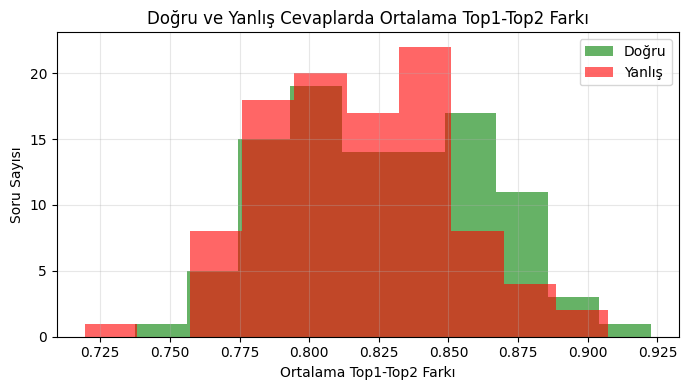

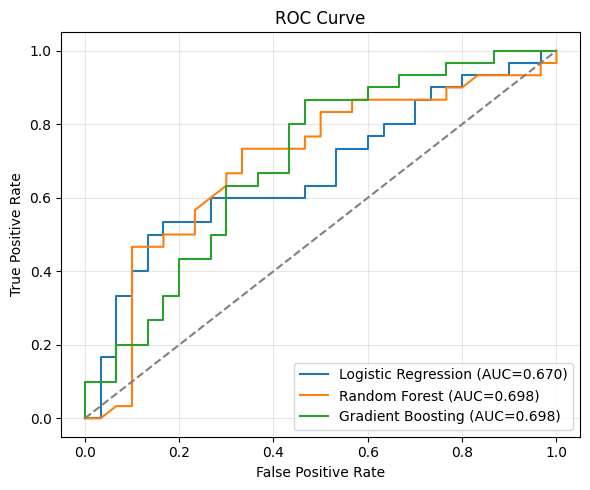

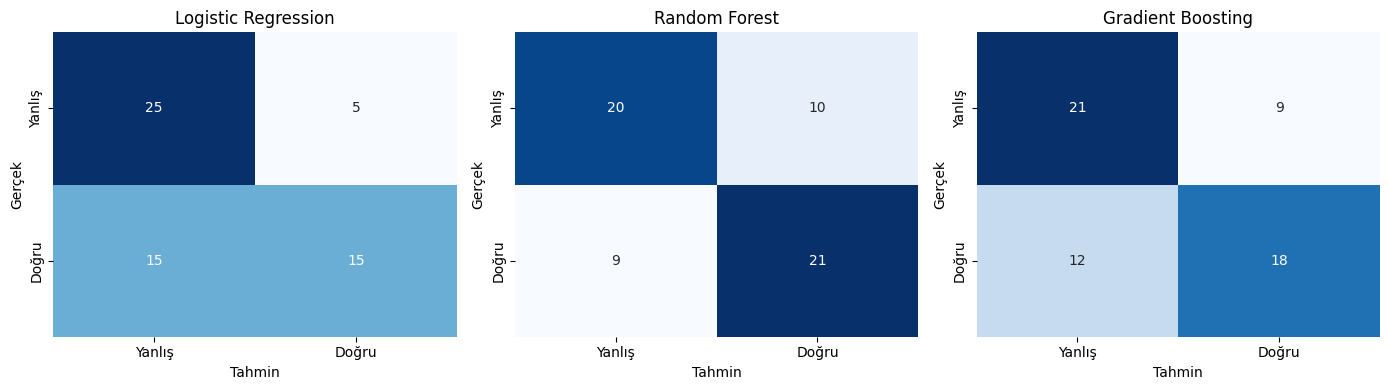

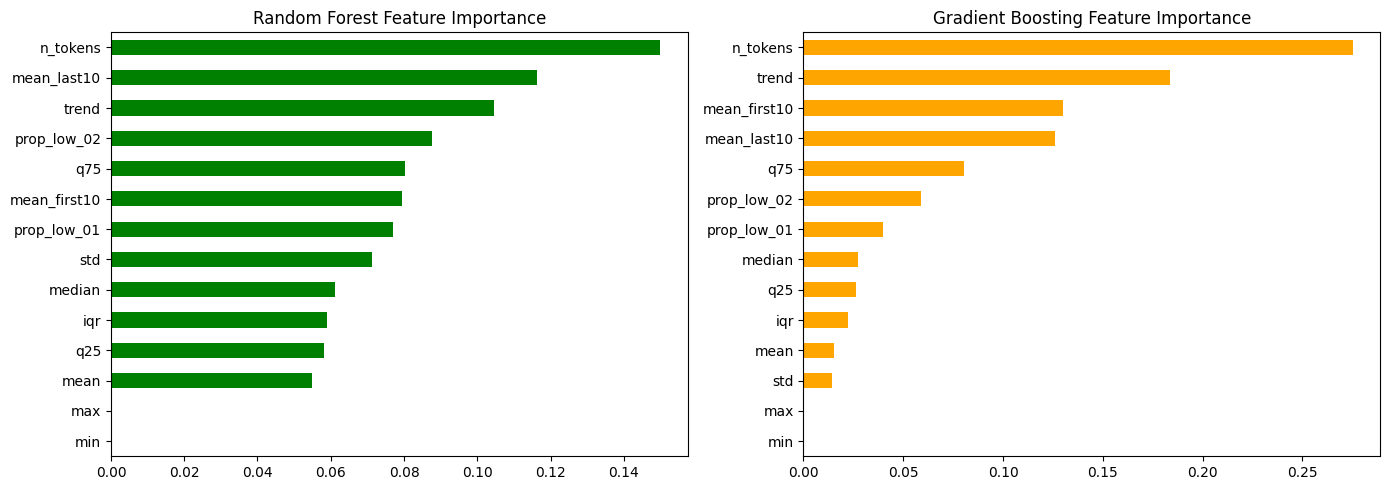

Figürler kaydedildi: /content/drive/MyDrive/HA_but/figures


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import seaborn as sns

# 1. Ortalama top1-top2 dağılımı
plt.figure(figsize=(7, 4))
plt.hist(df_dengeli[df_dengeli["dogru"] == 1]["mean"], alpha=0.6, label="Doğru", color="green")
plt.hist(df_dengeli[df_dengeli["dogru"] == 0]["mean"], alpha=0.6, label="Yanlış", color="red")
plt.xlabel("Ortalama Top1-Top2 Farkı")
plt.ylabel("Soru Sayısı")
plt.title("Doğru ve Yanlış Cevaplarda Ortalama Top1-Top2 Farkı")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_mean_diff_distribution.png", dpi=200)
plt.show()

# 2. ROC
plt.figure(figsize=(6, 5))
for ad in modeller.keys():
    fpr, tpr, _ = roc_curve(y_test, tahminler[ad]["prob"])
    auc = roc_auc_score(y_test, tahminler[ad]["prob"])
    plt.plot(fpr, tpr, label=f"{ad} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_roc.png", dpi=200)
plt.show()

# 3. Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, ad in zip(axes, modeller.keys()):
    cm = confusion_matrix(y_test, tahminler[ad]["pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Yanlış", "Doğru"],
        yticklabels=["Yanlış", "Doğru"],
        ax=ax
    )
    ax.set_title(ad)
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")

plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_confusion_matrix.png", dpi=200)
plt.show()

# 4. Feature importance
rf = modeller["Random Forest"]
gb = modeller["Gradient Boosting"]

rf_imp = pd.Series(rf.feature_importances_, index=ozellikler).sort_values()
gb_imp = pd.Series(gb.feature_importances_, index=ozellikler).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp.plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Random Forest Feature Importance")

gb_imp.plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_feature_importance.png", dpi=200)
plt.show()

print("Figürler kaydedildi:", FIG_KLASORU)

In [10]:
import os, json, time

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"

HEDEF_DOGRU = 250
HEDEF_YANLIS = 250
N_RUN = 1500
KAYIT_ARALIGI = 20

def kayitlari_oku(path):
    if not os.path.exists(path):
        return []

    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar


def kayitlari_yaz(path, yeni_kayitlar):
    if len(yeni_kayitlar) == 0:
        return

    with open(path, "a", encoding="utf-8") as f:
        for kayit in yeni_kayitlar:
            f.write(json.dumps(kayit, ensure_ascii=False) + "\n")


kayitlar = kayitlari_oku(KAYIT_DOSYASI)

islenen_idler = set(r["id"] for r in kayitlar)
dogru_sayisi = sum(r["dogru"] for r in kayitlar)
yanlis_sayisi = len(kayitlar) - dogru_sayisi

bekleyen_kayitlar = []

print("Önceki kayıt:", len(kayitlar))
print("Doğru:", dogru_sayisi, "Yanlış:", yanlis_sayisi)

basla = time.time()

for q in sorular[:N_RUN]:
    if q["id"] in islenen_idler:
        continue

    metin, diffs = uret(q["soru"])

    pred = pred_cevap(metin)
    dogru = pred is not None and abs(pred - q["gold"]) < 1e-4

    kayit = {
        "id": q["id"],
        "soru": q["soru"],
        "gold": q["gold"],
        "pred": pred,
        "dogru": dogru,
        "diffs": diffs,
        "n_token": len(diffs),
        "metin_kismi": metin[:500],
        "metin_son": metin[-500:]
    }

    bekleyen_kayitlar.append(kayit)
    islenen_idler.add(q["id"])

    if dogru:
        dogru_sayisi += 1
    else:
        yanlis_sayisi += 1

    print(
        f"[{len(islenen_idler)}] "
        f"gold={q['gold']} pred={pred} "
        f"{'DOĞRU' if dogru else 'YANLIŞ'} "
        f"token={len(diffs)} | "
        f"D={dogru_sayisi} Y={yanlis_sayisi}"
    )

    if len(bekleyen_kayitlar) >= KAYIT_ARALIGI:
        kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)
        bekleyen_kayitlar = []
        print("Ara kayıt yazıldı.")

    if dogru_sayisi >= HEDEF_DOGRU and yanlis_sayisi >= HEDEF_YANLIS:
        print("\n100 doğru + 100 yanlış veri toplandı.")
        break

kayitlari_yaz(KAYIT_DOSYASI, bekleyen_kayitlar)

son_kayitlar = kayitlari_oku(KAYIT_DOSYASI)

print("\n=== SON DURUM ===")
print("Toplam kayıt:", len(son_kayitlar))
print("Doğru:", sum(r["dogru"] for r in son_kayitlar))
print("Yanlış:", len(son_kayitlar) - sum(r["dogru"] for r in son_kayitlar))
print("Kayıt dosyası:", KAYIT_DOSYASI)
print(f"Süre: {(time.time() - basla)/60:.1f} dk")

Önceki kayıt: 217
Doğru: 117 Yanlış: 100
[218] gold=280.0 pred=1.12 YANLIŞ token=1024 | D=117 Y=101
[219] gold=480.0 pred=1.25 YANLIŞ token=1024 | D=117 Y=102
[220] gold=3.0 pred=2.0 YANLIŞ token=1024 | D=117 Y=103
[221] gold=2.0 pred=5.0 YANLIŞ token=641 | D=117 Y=104
[222] gold=65.0 pred=200.0 YANLIŞ token=1024 | D=117 Y=105
[223] gold=50.0 pred=50.0 DOĞRU token=866 | D=118 Y=105
[224] gold=30.0 pred=2.0 YANLIŞ token=1024 | D=118 Y=106
[225] gold=27.0 pred=28.0 YANLIŞ token=505 | D=118 Y=107
[226] gold=38.0 pred=8.0 YANLIŞ token=1024 | D=118 Y=108
[227] gold=20.0 pred=10.0 YANLIŞ token=1024 | D=118 Y=109
[228] gold=250.0 pred=315.0 YANLIŞ token=1024 | D=118 Y=110
[229] gold=35.0 pred=35.0 DOĞRU token=1024 | D=119 Y=110
[230] gold=200.0 pred=600.0 YANLIŞ token=1024 | D=119 Y=111
[231] gold=18.0 pred=18.0 DOĞRU token=567 | D=120 Y=111
[232] gold=21.0 pred=21.0 DOĞRU token=1024 | D=121 Y=111
[233] gold=91.0 pred=40.0 YANLIŞ token=1024 | D=121 Y=112
[234] gold=75.0 pred=75.0 DOĞRU token=

KeyboardInterrupt: 

In [12]:
# FINAL TEST HÜCRESİ
# Mevcut veri: D=187, Y=170
# Train: 145 doğru + 145 yanlış = 290
# Test : 25 doğru + 25 yanlış = 50

import os, json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"
SONUC_KLASORU = "/content/drive/MyDrive/HA_but/sonuclar"
os.makedirs(SONUC_KLASORU, exist_ok=True)

def kayitlari_oku(path):
    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar

def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)

    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df = pd.DataFrame(satirlar)

dogru_sayi = int(df["dogru"].sum())
yanlis_sayi = int(len(df) - dogru_sayi)
N_CLASS = min(dogru_sayi, yanlis_sayi)

print("Toplam kayıt:", len(df))
print("Doğru:", dogru_sayi)
print("Yanlış:", yanlis_sayi)
print("Dengeli kullanılabilir sınıf sayısı:", N_CLASS)

N_TEST_CLASS = 25
N_TRAIN_CLASS = N_CLASS - N_TEST_CLASS

if N_TRAIN_CLASS <= 0:
    raise ValueError("Yeterli veri yok. En az 26 doğru ve 26 yanlış gerekir.")

dogru_df = df[df["dogru"] == 1].sample(n=N_CLASS, random_state=42)
yanlis_df = df[df["dogru"] == 0].sample(n=N_CLASS, random_state=42)

dogru_train = dogru_df.sample(n=N_TRAIN_CLASS, random_state=42)
yanlis_train = yanlis_df.sample(n=N_TRAIN_CLASS, random_state=42)

dogru_test = dogru_df.drop(dogru_train.index).sample(n=N_TEST_CLASS, random_state=42)
yanlis_test = yanlis_df.drop(yanlis_train.index).sample(n=N_TEST_CLASS, random_state=42)

df_train = pd.concat([dogru_train, yanlis_train]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([dogru_test, yanlis_test]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df.columns if c not in ["dogru", "id"]]

X_train = df_train[ozellikler]
y_train = df_train["dogru"]

X_test = df_test[ozellikler]
y_test = df_test["dogru"]

print("\n=== VERİ AYRIMI ===")
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train doğru:", int(y_train.sum()), "yanlış:", int(len(y_train) - y_train.sum()))
print("Test doğru :", int(y_test.sum()), "yanlış:", int(len(y_test) - y_test.sum()))

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

sonuclar = []
tahminler = {}

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)

    pred = model_ml.predict(X_test)
    prob = model_ml.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred)

    sonuclar.append({
        "Model": ad,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    tahminler[ad] = {
        "pred": pred,
        "prob": prob,
        "cm": cm
    }

    print("\n" + ad)
    print(cm)

sonuc_df = pd.DataFrame(sonuclar)
display(sonuc_df)

df.to_csv(f"{SONUC_KLASORU}/ozellikler_tum.csv", index=False)
df_train.to_csv(f"{SONUC_KLASORU}/train_290.csv", index=False)
df_test.to_csv(f"{SONUC_KLASORU}/test_50.csv", index=False)
sonuc_df.to_csv(f"{SONUC_KLASORU}/model_sonuclari_test50.csv", index=False)

print("\nKaydedildi:")
print(f"{SONUC_KLASORU}/ozellikler_tum.csv")
print(f"{SONUC_KLASORU}/train_290.csv")
print(f"{SONUC_KLASORU}/test_50.csv")
print(f"{SONUC_KLASORU}/model_sonuclari_test50.csv")

Toplam kayıt: 357
Doğru: 187
Yanlış: 170
Dengeli kullanılabilir sınıf sayısı: 170

=== VERİ AYRIMI ===
Train: (290, 14)
Test : (50, 14)
Train doğru: 145 yanlış: 145
Test doğru : 25 yanlış: 25

Logistic Regression
[[24  1]
 [10 15]]

Random Forest
[[15 10]
 [ 8 17]]

Gradient Boosting
[[15 10]
 [ 6 19]]


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.78,0.937500,0.60,0.731707,0.7824
1,Random Forest,0.64,0.629630,0.68,0.653846,0.7888
2,Gradient Boosting,0.68,0.655172,0.76,0.703704,0.7328



Kaydedildi:
/content/drive/MyDrive/HA_but/sonuclar/ozellikler_tum.csv
/content/drive/MyDrive/HA_but/sonuclar/train_290.csv
/content/drive/MyDrive/HA_but/sonuclar/test_50.csv
/content/drive/MyDrive/HA_but/sonuclar/model_sonuclari_test50.csv


In [ ]:
# FINAL TEST HÜCRESİ
# Mevcut veri: D=187, Y=170
# Train: 145 doğru + 145 yanlış = 290
# Test : 25 doğru + 25 yanlış = 50

import os, json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"
SONUC_KLASORU = "/content/drive/MyDrive/HA_but/sonuclar"
os.makedirs(SONUC_KLASORU, exist_ok=True)

def kayitlari_oku(path):
    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar

def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)

    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df = pd.DataFrame(satirlar)

dogru_sayi = int(df["dogru"].sum())
yanlis_sayi = int(len(df) - dogru_sayi)
N_CLASS = min(dogru_sayi, yanlis_sayi)

print("Toplam kayıt:", len(df))
print("Doğru:", dogru_sayi)
print("Yanlış:", yanlis_sayi)
print("Dengeli kullanılabilir sınıf sayısı:", N_CLASS)

N_TEST_CLASS = 25
N_TRAIN_CLASS = N_CLASS - N_TEST_CLASS

if N_TRAIN_CLASS <= 0:
    raise ValueError("Yeterli veri yok. En az 26 doğru ve 26 yanlış gerekir.")

dogru_df = df[df["dogru"] == 1].sample(n=N_CLASS, random_state=42)
yanlis_df = df[df["dogru"] == 0].sample(n=N_CLASS, random_state=42)

dogru_train = dogru_df.sample(n=N_TRAIN_CLASS, random_state=42)
yanlis_train = yanlis_df.sample(n=N_TRAIN_CLASS, random_state=42)

dogru_test = dogru_df.drop(dogru_train.index).sample(n=N_TEST_CLASS, random_state=42)
yanlis_test = yanlis_df.drop(yanlis_train.index).sample(n=N_TEST_CLASS, random_state=42)

df_train = pd.concat([dogru_train, yanlis_train]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([dogru_test, yanlis_test]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df.columns if c not in ["dogru", "id"]]

X_train = df_train[ozellikler]
y_train = df_train["dogru"]

X_test = df_test[ozellikler]
y_test = df_test["dogru"]

print("\n=== VERİ AYRIMI ===")
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train doğru:", int(y_train.sum()), "yanlış:", int(len(y_train) - y_train.sum()))
print("Test doğru :", int(y_test.sum()), "yanlış:", int(len(y_test) - y_test.sum()))

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

sonuclar = []
tahminler = {}

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)

    pred = model_ml.predict(X_test)
    prob = model_ml.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred)

    sonuclar.append({
        "Model": ad,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    tahminler[ad] = {
        "pred": pred,
        "prob": prob,
        "cm": cm
    }

    print("\n" + ad)
    print(cm)

sonuc_df = pd.DataFrame(sonuclar)
display(sonuc_df)

df.to_csv(f"{SONUC_KLASORU}/ozellikler_tum.csv", index=False)
df_train.to_csv(f"{SONUC_KLASORU}/train_290.csv", index=False)
df_test.to_csv(f"{SONUC_KLASORU}/test_50.csv", index=False)
sonuc_df.to_csv(f"{SONUC_KLASORU}/model_sonuclari_test50.csv", index=False)

print("\nKaydedildi:")
print(f"{SONUC_KLASORU}/ozellikler_tum.csv")
print(f"{SONUC_KLASORU}/train_290.csv")
print(f"{SONUC_KLASORU}/test_50.csv")
print(f"{SONUC_KLASORU}/model_sonuclari_test50.csv")

In [13]:
# FINAL TEST HÜCRESİ
# Train: 120 doğru + 120 yanlış = 240
# Test : 50 doğru + 50 yanlış = 100

import os, json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

KAYIT_DOSYASI = "/content/drive/MyDrive/HA_but/cosmos_t1_kayitlar_768.jsonl"
SONUC_KLASORU = "/content/drive/MyDrive/HA_but/sonuclar"
os.makedirs(SONUC_KLASORU, exist_ok=True)

def kayitlari_oku(path):
    kayitlar = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                kayitlar.append(json.loads(line))
    return kayitlar

def ozellik_cikar(diffs):
    x = np.array(diffs, dtype=float)

    if len(x) == 0:
        x = np.array([0.0])

    ilk10 = x[:10]
    son10 = x[-10:]

    if len(x) > 1:
        t = np.arange(len(x))
        trend = np.polyfit(t, x, 1)[0]
    else:
        trend = 0.0

    return {
        "n_tokens": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mean_first10": np.mean(ilk10),
        "mean_last10": np.mean(son10),
        "prop_low_01": np.mean(x < 0.10),
        "prop_low_02": np.mean(x < 0.20),
        "trend": trend
    }

kayitlar = kayitlari_oku(KAYIT_DOSYASI)

satirlar = []
for r in kayitlar:
    o = ozellik_cikar(r["diffs"])
    o["dogru"] = int(r["dogru"])
    o["id"] = r["id"]
    satirlar.append(o)

df = pd.DataFrame(satirlar)

dogru_sayi = int(df["dogru"].sum())
yanlis_sayi = int(len(df) - dogru_sayi)
N_CLASS = min(dogru_sayi, yanlis_sayi)

print("Toplam kayıt:", len(df))
print("Doğru:", dogru_sayi)
print("Yanlış:", yanlis_sayi)
print("Dengeli kullanılabilir sınıf sayısı:", N_CLASS)

N_TEST_CLASS = 50
N_TRAIN_CLASS = N_CLASS - N_TEST_CLASS

if N_TRAIN_CLASS <= 0:
    raise ValueError("Yeterli veri yok. En az 51 doğru ve 51 yanlış gerekir.")

dogru_df = df[df["dogru"] == 1].sample(n=N_CLASS, random_state=42)
yanlis_df = df[df["dogru"] == 0].sample(n=N_CLASS, random_state=42)

dogru_train = dogru_df.sample(n=N_TRAIN_CLASS, random_state=42)
yanlis_train = yanlis_df.sample(n=N_TRAIN_CLASS, random_state=42)

dogru_test = dogru_df.drop(dogru_train.index).sample(n=N_TEST_CLASS, random_state=42)
yanlis_test = yanlis_df.drop(yanlis_train.index).sample(n=N_TEST_CLASS, random_state=42)

df_train = pd.concat([dogru_train, yanlis_train]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([dogru_test, yanlis_test]).sample(frac=1, random_state=42).reset_index(drop=True)

ozellikler = [c for c in df.columns if c not in ["dogru", "id"]]

X_train = df_train[ozellikler]
y_train = df_train["dogru"]

X_test = df_test[ozellikler]
y_test = df_test["dogru"]

print("\n=== VERİ AYRIMI ===")
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train doğru:", int(y_train.sum()), "yanlış:", int(len(y_train) - y_train.sum()))
print("Test doğru :", int(y_test.sum()), "yanlış:", int(len(y_test) - y_test.sum()))

modeller = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

sonuclar = []
tahminler = {}

for ad, model_ml in modeller.items():
    model_ml.fit(X_train, y_train)

    pred = model_ml.predict(X_test)
    prob = model_ml.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred)

    sonuclar.append({
        "Model": ad,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    tahminler[ad] = {
        "pred": pred,
        "prob": prob,
        "cm": cm
    }

    print("\n" + ad)
    print(cm)

sonuc_df = pd.DataFrame(sonuclar)
display(sonuc_df)

df.to_csv(f"{SONUC_KLASORU}/ozellikler_tum.csv", index=False)
df_train.to_csv(f"{SONUC_KLASORU}/train_240.csv", index=False)
df_test.to_csv(f"{SONUC_KLASORU}/test_100.csv", index=False)
sonuc_df.to_csv(f"{SONUC_KLASORU}/model_sonuclari_test100.csv", index=False)

print("\nKaydedildi:")
print(f"{SONUC_KLASORU}/ozellikler_tum.csv")
print(f"{SONUC_KLASORU}/train_240.csv")
print(f"{SONUC_KLASORU}/test_100.csv")
print(f"{SONUC_KLASORU}/model_sonuclari_test100.csv")

Toplam kayıt: 357
Doğru: 187
Yanlış: 170
Dengeli kullanılabilir sınıf sayısı: 170

=== VERİ AYRIMI ===
Train: (240, 14)
Test : (100, 14)
Train doğru: 120 yanlış: 120
Test doğru : 50 yanlış: 50

Logistic Regression
[[45  5]
 [23 27]]

Random Forest
[[38 12]
 [18 32]]

Gradient Boosting
[[36 14]
 [14 36]]


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.72,0.843750,0.54,0.658537,0.7376
1,Random Forest,0.70,0.727273,0.64,0.680851,0.7470
2,Gradient Boosting,0.72,0.720000,0.72,0.720000,0.7620



Kaydedildi:
/content/drive/MyDrive/HA_but/sonuclar/ozellikler_tum.csv
/content/drive/MyDrive/HA_but/sonuclar/train_240.csv
/content/drive/MyDrive/HA_but/sonuclar/test_100.csv
/content/drive/MyDrive/HA_but/sonuclar/model_sonuclari_test100.csv


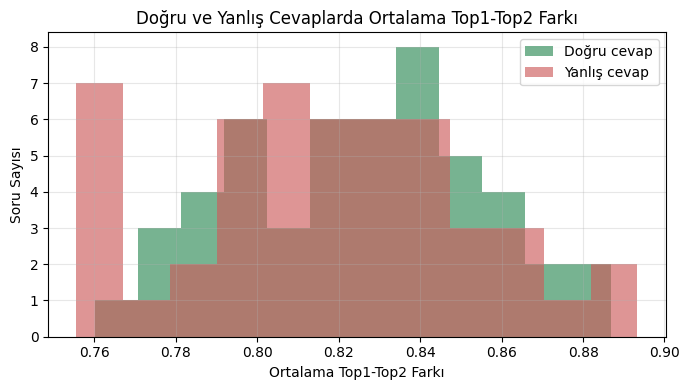

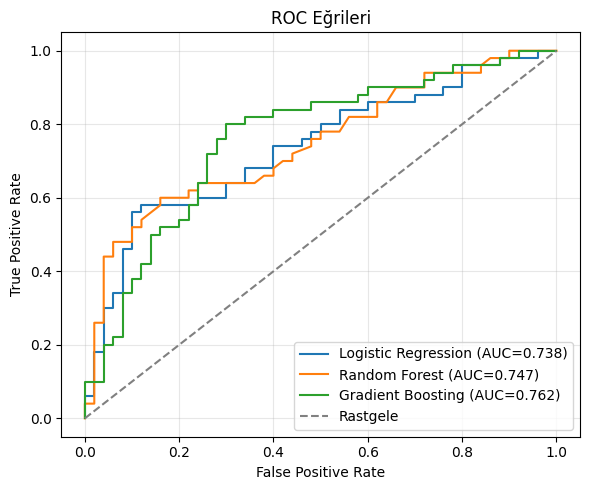

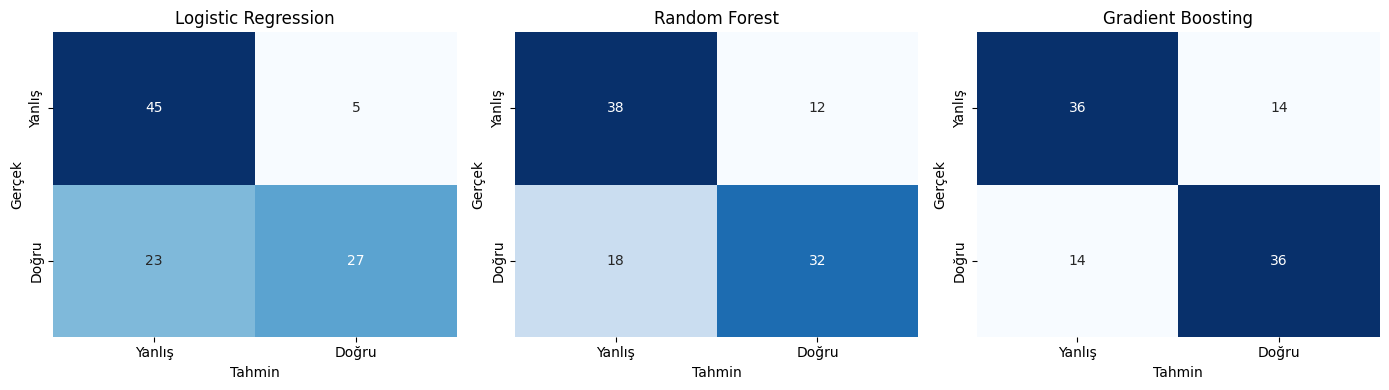

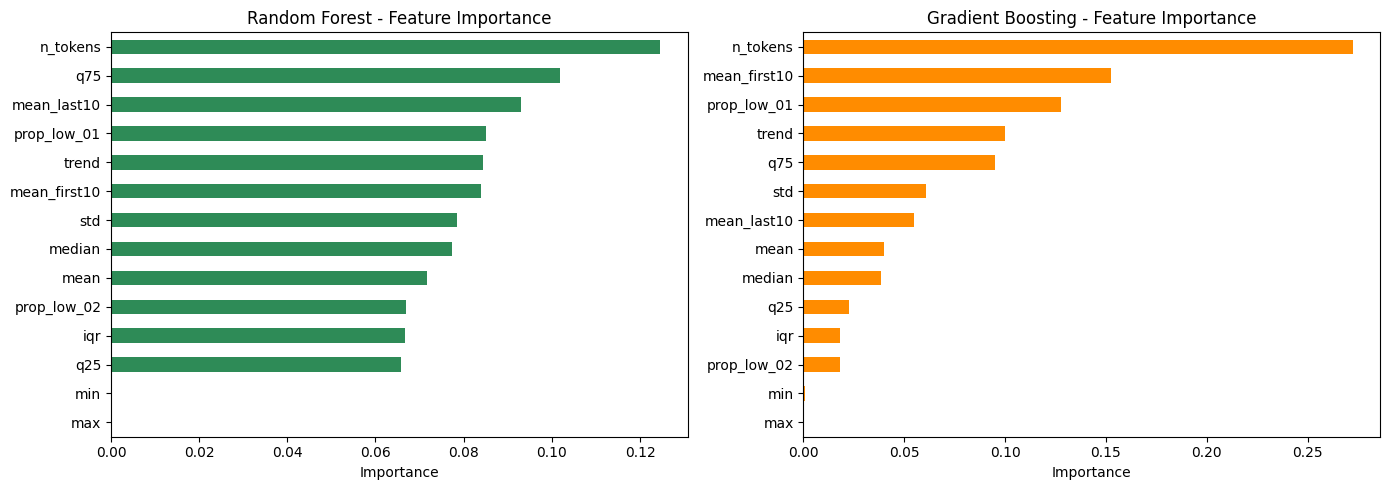

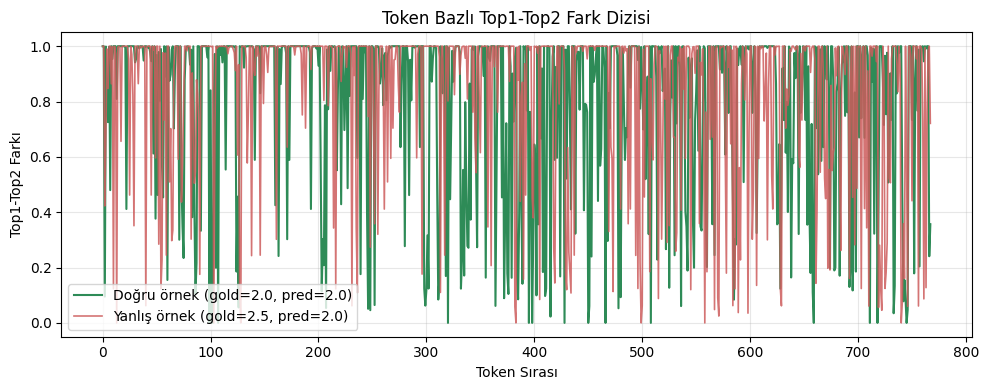

Figürler kaydedildi: /content/drive/MyDrive/HA_but/figures


In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

FIG_KLASORU = "/content/drive/MyDrive/HA_but/figures"
os.makedirs(FIG_KLASORU, exist_ok=True)

# 1. Ortalama top1-top2 fark dağılımı
plt.figure(figsize=(7, 4))
plt.hist(
    df_test[df_test["dogru"] == 1]["mean"],
    alpha=0.65,
    label="Doğru cevap",
    color="seagreen",
    bins=12
)
plt.hist(
    df_test[df_test["dogru"] == 0]["mean"],
    alpha=0.65,
    label="Yanlış cevap",
    color="indianred",
    bins=12
)
plt.xlabel("Ortalama Top1-Top2 Farkı")
plt.ylabel("Soru Sayısı")
plt.title("Doğru ve Yanlış Cevaplarda Ortalama Top1-Top2 Farkı")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_mean_diff_distribution.png", dpi=200)
plt.show()


# 2. ROC eğrileri
plt.figure(figsize=(6, 5))

for ad in modeller.keys():
    fpr, tpr, _ = roc_curve(y_test, tahminler[ad]["prob"])
    auc = roc_auc_score(y_test, tahminler[ad]["prob"])
    plt.plot(fpr, tpr, label=f"{ad} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="Rastgele")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_roc.png", dpi=200)
plt.show()


# 3. Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, ad in zip(axes, modeller.keys()):
    cm = confusion_matrix(y_test, tahminler[ad]["pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Yanlış", "Doğru"],
        yticklabels=["Yanlış", "Doğru"],
        ax=ax
    )
    ax.set_title(ad)
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")

plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_confusion_matrix.png", dpi=200)
plt.show()


# 4. Feature importance
rf = modeller["Random Forest"]
gb = modeller["Gradient Boosting"]

rf_imp = pd.Series(rf.feature_importances_, index=ozellikler).sort_values()
gb_imp = pd.Series(gb.feature_importances_, index=ozellikler).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp.plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Random Forest - Feature Importance")
axes[0].set_xlabel("Importance")

gb_imp.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting - Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_feature_importance.png", dpi=200)
plt.show()


# 5. Token bazlı top1-top2 farkı: bir doğru ve bir yanlış örnek
test_ids = set(df_test["id"].tolist())

dogru_ornek = None
yanlis_ornek = None

for r in kayitlar:
    if r["id"] in test_ids and r["dogru"] == True and dogru_ornek is None:
        dogru_ornek = r
    if r["id"] in test_ids and r["dogru"] == False and yanlis_ornek is None:
        yanlis_ornek = r

    if dogru_ornek is not None and yanlis_ornek is not None:
        break

plt.figure(figsize=(10, 4))

if dogru_ornek is not None:
    plt.plot(
        dogru_ornek["diffs"],
        label=f"Doğru örnek (gold={dogru_ornek['gold']}, pred={dogru_ornek['pred']})",
        color="seagreen",
        linewidth=1.5
    )

if yanlis_ornek is not None:
    plt.plot(
        yanlis_ornek["diffs"],
        label=f"Yanlış örnek (gold={yanlis_ornek['gold']}, pred={yanlis_ornek['pred']})",
        color="indianred",
        linewidth=1.2,
        alpha=0.85
    )

plt.xlabel("Token Sırası")
plt.ylabel("Top1-Top2 Farkı")
plt.title("Token Bazlı Top1-Top2 Fark Dizisi")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_KLASORU}/fig_token_level_diff.png", dpi=200)
plt.show()

print("Figürler kaydedildi:", FIG_KLASORU)